In [21]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

,id,league_id,season,stage,match_api_id,local,team_api_id,team_goal
0,0,1,2008/2009,24,493017,away,9987,1
1,1,1,2008/2009,24,493017,home,8203,2
2,2,1,2008/2009,25,493025,away,8342,3
3,3,1,2008/2009,25,493025,home,9984,1
4,4,1,2008/2009,25,493027,away,10000,0
...,...,...,...,...,...,...,...,...
42717,42717,24558,2015/2016,36,1992227,home,10199,2
42718,42718,24558,2015/2016,36,1992228,away,10192,3
42719,42719,24558,2015/2016,36,1992228,home,10191,0
42720,42720,24558,2015/2016,36,1992229,away,9824,1


<Axes: xlabel='team_api_id'>

Text(0.5, 1.0, '2015/2016赛季球队进球数排行')

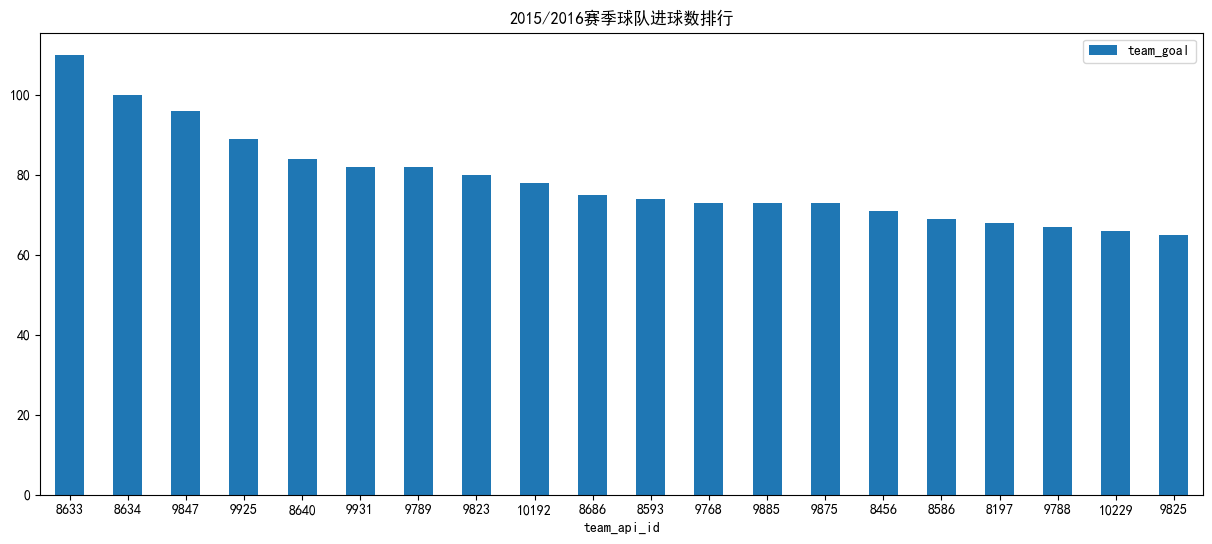

In [22]:
# 2015/2016赛季球队进球数的排行
df = pd.read_csv('data/match_goal.csv')
df
a=df.query('season=="2015/2016"').groupby('team_api_id')['team_goal'].sum()
a=a.sort_values(ascending=False).head(20)
a.plot.bar(x='team_api_id',figsize=(15,6),rot=0)
plt.title('2015/2016赛季球队进球数排行')
plt.legend(bbox_to_anchor=(1,1))

,id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,finishing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,0,505942,2016/2/18 0:00,67.0,71.0,right,medium,medium,49.0,44.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,1,505942,2015/11/19 0:00,67.0,71.0,right,medium,medium,49.0,44.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,2,505942,2015/9/21 0:00,62.0,66.0,right,medium,medium,49.0,44.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,3,505942,2015/3/20 0:00,61.0,65.0,right,medium,medium,48.0,43.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,4,505942,2007/2/22 0:00,61.0,65.0,right,medium,medium,48.0,43.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183973,183973,39902,2009/8/30 0:00,83.0,85.0,right,medium,low,84.0,77.0,...,88.0,83.0,22.0,31.0,30.0,9.0,20.0,84.0,20.0,20.0
183974,183974,39902,2009/2/22 0:00,78.0,80.0,right,medium,low,74.0,76.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183975,183975,39902,2008/8/30 0:00,77.0,80.0,right,medium,low,74.0,71.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183976,183976,39902,2007/8/30 0:00,78.0,81.0,right,medium,low,74.0,64.0,...,88.0,53.0,28.0,32.0,30.0,9.0,20.0,73.0,20.0,20.0


<Axes: xlabel='overall_rating', ylabel='potential'>

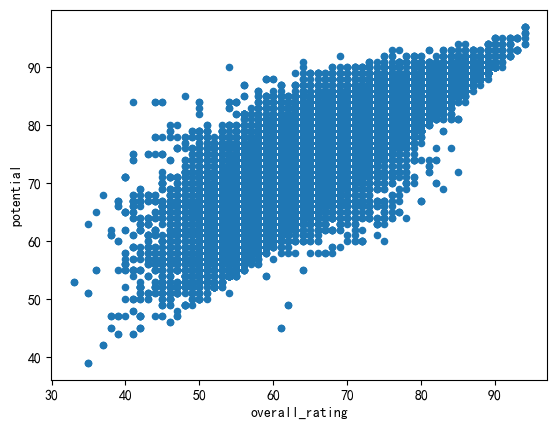

<Axes: xlabel='overall_rating', ylabel='potential'>

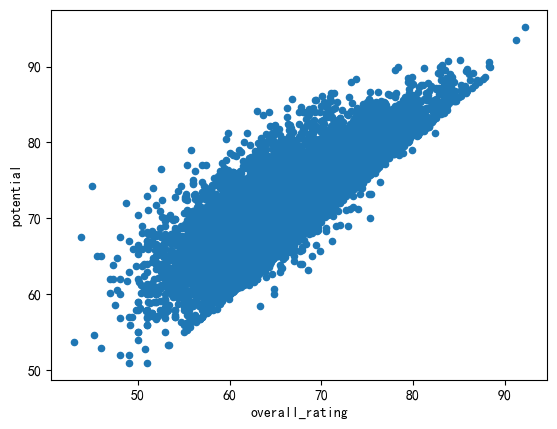

In [23]:
# 球员的评分与潜能的关系
df = pd.read_csv('data/player_attributes.csv')
df
# 全部数据评分与潜能的关系
df[['overall_rating','potential']].plot.scatter(x='overall_rating',y='potential',)
plt.show()
# >每个球员平均评分与平均潜能的关系
df.groupby('player_api_id')[['overall_rating','potential']].mean().plot.scatter(x='overall_rating',y='potential')

,id,league_id,season,stage,match_api_id,local,team_api_id,team_goal
0,0,1,2008/2009,24,493017,away,9987,1
1,1,1,2008/2009,24,493017,home,8203,2
2,2,1,2008/2009,25,493025,away,8342,3
3,3,1,2008/2009,25,493025,home,9984,1
4,4,1,2008/2009,25,493027,away,10000,0


season
2008/2009    4579
2009/2010    6722
2010/2011    7323
2011/2012    7720
2012/2013    8045
2013/2014    7712
2014/2015    7984
2015/2016    8288
Name: team_goal, dtype: int64

team_goal    Axes(0.125,0.11;0.775x0.77)
dtype: object

Text(0.5, 1.0, 'Boxplot grouped by seasonteam_goal')

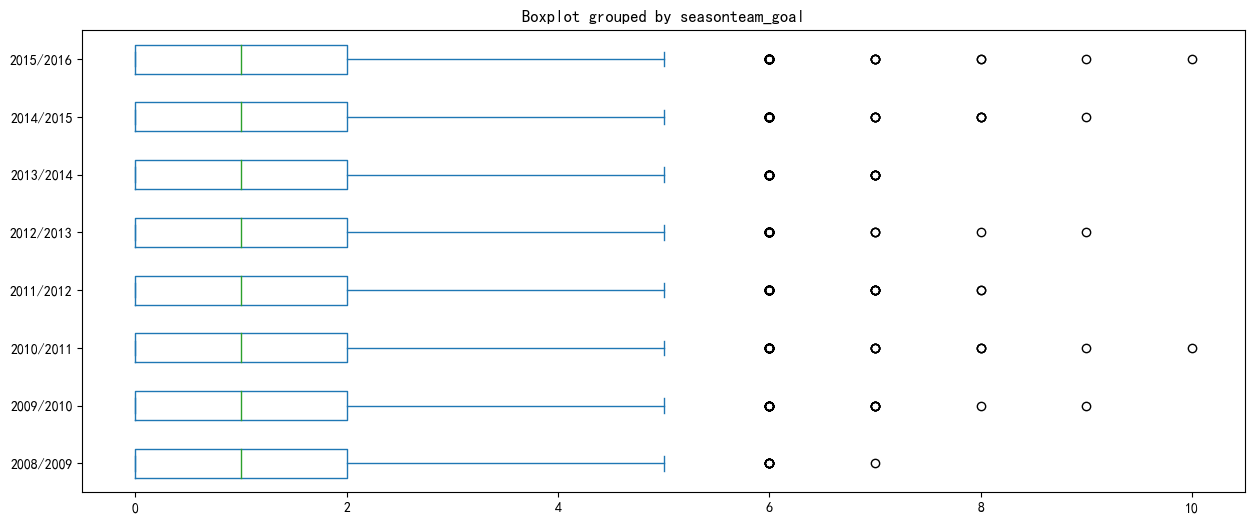

In [24]:
# 各赛季进球数的异常值检测
df = pd.read_csv('data/match_goal.csv')
df.head()
# >对于全部比赛数据按赛季进行统计进球数
# >使用箱形图实现进球分布以及异常值检测
df.groupby('season')['team_goal'].sum()
df.plot.box(by='season',column='team_goal',figsize=(15,6),vert=False)
plt.title('Boxplot grouped by seasonteam_goal')

<Axes: ylabel='Frequency'>

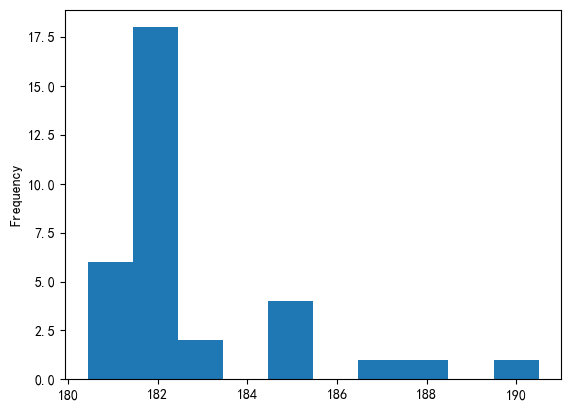

<Axes: ylabel='Density'>

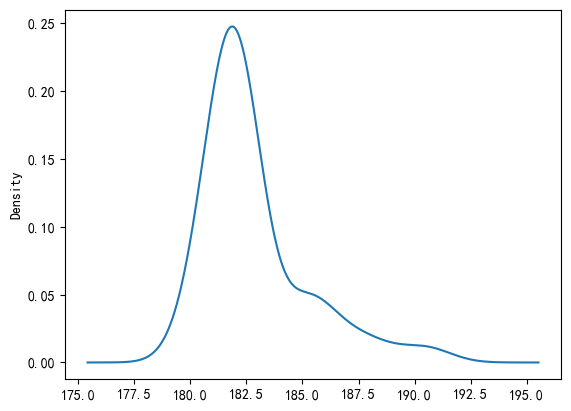

<Axes: ylabel='Frequency'>

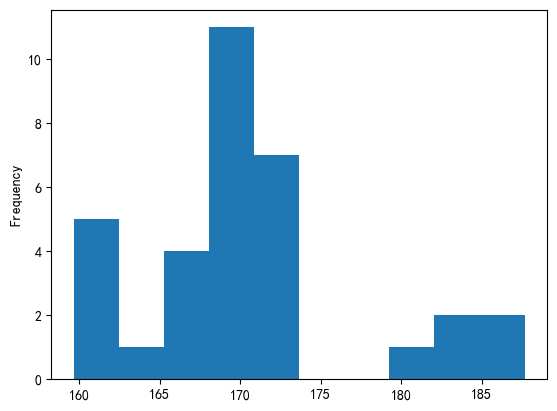

<Axes: ylabel='Density'>

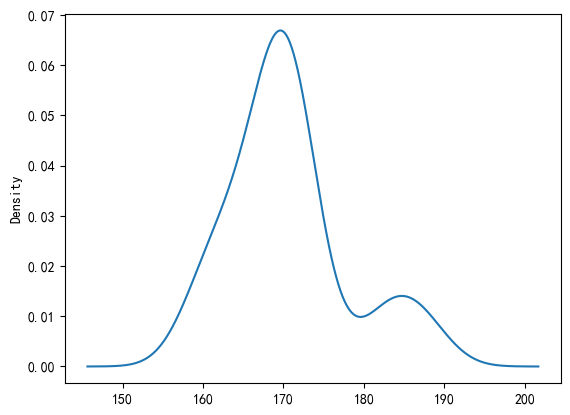

array([[<Axes: title={'center': 'height'}>,
        <Axes: title={'center': 'weight'}>]], dtype=object)

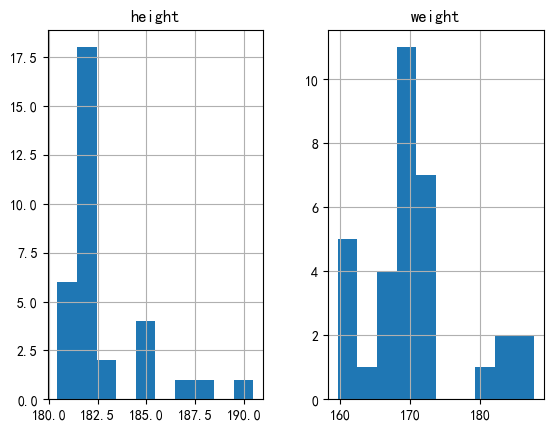

<Axes: ylabel='Frequency'>

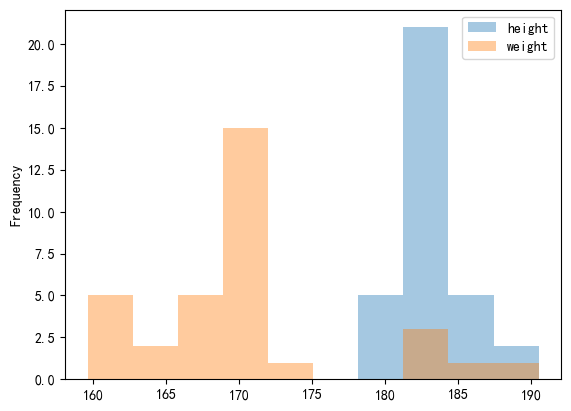

<Axes: ylabel='Density'>

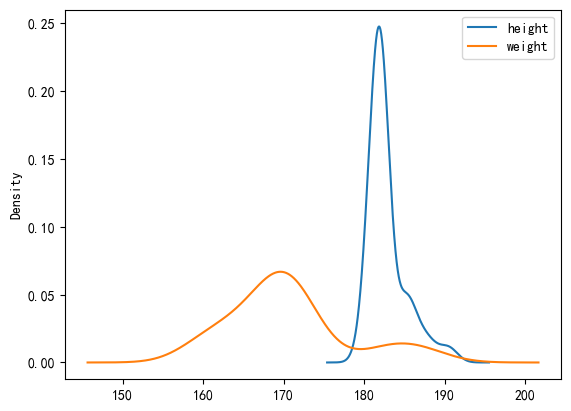

In [25]:
# Pandas不同年出生球员平均身高、体重对比统计
df = pd.read_csv('data/player.csv')
# df.drop('Unnamed: 0',axis=1,inplace=True)
# df.head()
# >按出生年份分组，实现球员的平均身高直方图与核密度图统计
df.birthday=pd.to_datetime(df.birthday)
df.groupby(df.birthday.dt.year)['height'].mean().round(2).plot.hist()
plt.show()
df.groupby(df.birthday.dt.year)['height'].mean().round(2).plot.kde()
plt.show()
# 按出生年份分组，实现球员的平均体重直方图与核密度图统计
df.groupby(df.birthday.dt.year)['weight'].mean().round(2).plot.hist()
plt.show()
df.groupby(df.birthday.dt.year)['weight'].mean().round(2).plot.kde()
plt.show()
# 按出生年份分组，绘制平均身高和平均体重分布的分面直方图
df.groupby(df.birthday.dt.year)[['height','weight']].mean().round(2).hist()
plt.show()
# 按出生年份分组，在同一绘图中绘制平均身高和平均体重直方图
df.groupby(df.birthday.dt.year)[['height','weight']].mean().round(2).plot.hist(alpha=0.4)
plt.show()
# 按出生年份分组，在同一绘图中绘制平均身高和平均体重核密度图
df.groupby(df.birthday.dt.year)[['height','weight']].mean().round(2).plot.kde()
plt.show()

,player_api_id,player_name,birthday,height,weight
0,505942,Aaron Appindangoye,1992-02-29 00:00:00,182.88,187
1,155782,Aaron Cresswell,1989-12-15 00:00:00,170.18,146
2,162549,Aaron Doran,1991-05-13 00:00:00,170.18,163
3,30572,Aaron Galindo,1982-05-08 00:00:00,182.88,198
4,23780,Aaron Hughes,1979-11-08 00:00:00,182.88,154


<Axes: xlabel='height', ylabel='Count'>

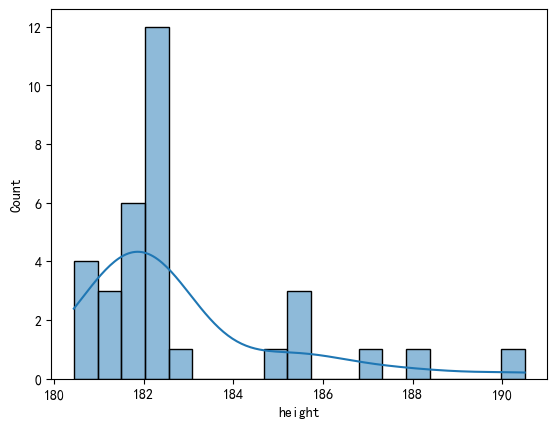

<Axes: xlabel='weight', ylabel='Count'>

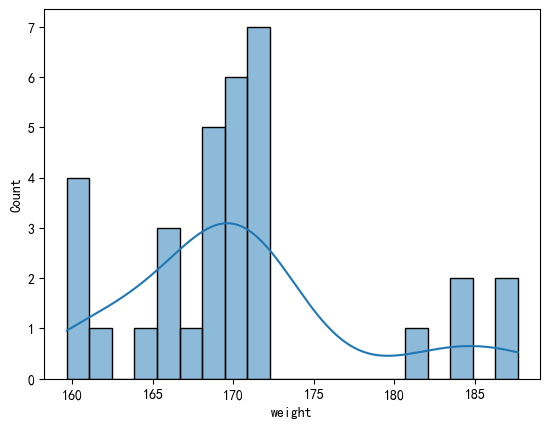

<Axes: ylabel='Count'>

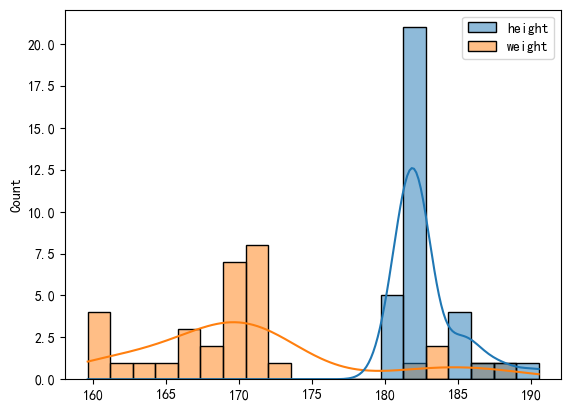

In [26]:
# Seaborn实现不同年出生球员平均身高、体重对比统计
df = pd.read_csv('data/player.csv')
# df.drop('Unnamed: 0',axis=1,inplace=True)
df.head()
from seaborn import histplot
# >按出生年份分组，实现球员的平均身高直方图与核密度图统计
df.birthday=pd.to_datetime(df.birthday)
df_height=df.groupby(df.birthday.dt.year)['height'].mean()
df_weight=df.groupby(df.birthday.dt.year)['weight'].mean()
histplot(df_height,kde=True)
plt.show()
# >按出生年份分组，实现球员的平均体重直方图与核密度图统计
histplot(df_weight,kde=True,bins=20)
plt.show()
# >按出生年份分组，在同一绘图中绘制平均身高和平均体重核密度图
histplot([df_height,df_weight],bins=20,kde=True)